In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Setup completato ✓")

Setup completato ✓


# ⚽ International Football Results — Analisi storica del calcio internazionale

**Nome e cognome**: Andres Pelizzer
**Dataset scelto**: International Football Results (1872–2025)
**Link Kaggle**: https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017

**Perché ho scelto questo dataset**: Sono un appassionato di calcio e volevo scoprire cosa si nasconde dietro 150 anni di partite internazionali — dal fattore campo al record dell'Italia.

---

### 📋 Le 5 domande di ricerca

1. **Q1** — Quante partite totali, quante nazionali, quanti tornei diversi? In che anno è la prima partita registrata?
2. **Q2** — Quali nazionali hanno vinto più partite di sempre? E con la più alta percentuale di vittorie (su almeno 100 partite)?
3. **Q3** — Il record dell'Italia: quante partite, vittorie/pareggi/sconfitte, qual è stato il decennio migliore e quello peggiore?
4. **Q4** — Esiste davvero il "fattore campo"? Le squadre di casa vincono più spesso? Nei tornei in campo neutrale come cambia?
5. **Q5** — Il calcio è diventato più offensivo o più difensivo nel tempo? Come è cambiato il numero medio di gol per partita dal 1900 a oggi?

**Bonus**: Le grandi rivalità — le 10 coppie di nazionali che si sono affrontate più volte, con il bilancio per ognuna.

In [3]:
df = pd.read_csv("results.csv")
print(f"Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
df.head()

Dataset caricato: 49287 righe × 9 colonne


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [5]:
df.describe()

,home_score,away_score
count,49215.000000,49215.000000
mean,1.756091,1.182404
std,1.770617,1.401770
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [6]:
tutte_le_squadre = pd.concat([df['home_team'], df['away_team']]).nunique()

print(f"Partite totali: {df.shape[0]}")
print(f"Nazionali diverse: {tutte_le_squadre}")
print(f"Tornei diversi: {df['tournament'].nunique()}")
print(f"Periodo: da {df['date'].min()} a {df['date'].max()}")

Partite totali: 49287
Nazionali diverse: 333
Tornei diversi: 193
Periodo: da 1872-11-30 a 2026-06-27


### 📝 Risposta Q1

Il dataset contiene **49.287 partite internazionali** disputate tra il 30 novembre 1872 e il 27 giugno 2026, coprendo oltre 150 anni di calcio. Sono presenti **333 nazionali diverse** e **193 tornei** (dalle amichevoli ai Mondiali). Le colonne chiave sono: data, squadra di casa/ospite, gol, torneo, città, paese e se il campo è neutro.

Da notare: 72 partite non hanno il risultato (gol mancanti) e la colonna `date` è salvata come stringa, va convertita. Il gol massimo registrato in casa è 31 — ci sono goleade estreme che potrebbero essere outlier da investigare.

## 🧹 Pulizia del dataset

In [7]:
# 1. Convertiamo la colonna date in formato datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Vediamo i valori mancanti
print("Valori mancanti per colonna:")
print(df.isna().sum())

# 3. Controlliamo i duplicati
print(f"\nRighe duplicate: {df.duplicated().sum()}")

Valori mancanti per colonna:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

Righe duplicate: 0


In [8]:
# Rimozione 72 partite senza risultato
df=df.dropna(subset=["home_score","away_score"])

# Convertire i gol in interi ( ora che non ci sono più Nan si può)
df["home_score"]=df["home_score"].astype(int)
df["away_score"]=df["away_score"].astype(int)

# Creiamo colonne utili per dopo
df["total_goals"]=df["home_score"] + df["away_score"]
df["year"]=df["date"].dt.year

print(f"Righe dopo pulizia:{df.shape[0]}")
print(f"Tipi aggiornati:")
print(df[["home_score","away_score","total_goals","year"]].dtypes)


Righe dopo pulizia:49215
Tipi aggiornati:
home_score     int64
away_score     int64
total_goals    int64
year           int32
dtype: object


### 📝 Pulizie effettuate

- **Convertita la colonna `date`** da stringa a datetime per poter estrarre anno, mese e decennio
- **Rimosse 72 partite** senza risultato (gol mancanti): sono lo 0.15% del dataset, irrilevanti
- **Convertiti i gol** da float a int, ora che i NaN non li forzano più in decimale
- **Create 2 colonne nuove**: `total_goals` (somma gol della partita) e `year` (anno), utili per le analisi temporali

## 📊 Q2 — Quali nazionali hanno vinto più partite? E con la più alta percentuale di vittorie?

In [11]:
vittorie_casa = df[df['home_score'] > df['away_score']]['home_team'].value_counts()
vittorie_fuori = df[df['away_score'] > df['home_score']]['away_team'].value_counts()
vittorie_totali=vittorie_casa.add(vittorie_fuori,fill_value=0).astype(int).sort_values(ascending=False)
vittorie_totali.head(10)

home_team
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470
Name: count, dtype: int64

In [14]:
partite_casa = df['home_team'].value_counts()
partite_fuori = df['away_team'].value_counts()
partite_totali=partite_casa.add(partite_fuori, fill_value=0).astype(int)

percentuale_vittorie=(vittorie_totali/partite_totali *100).round(1)
percentuale_vittorie = percentuale_vittorie[partite_totali >= 100].sort_values(ascending=False)

percentuale_vittorie.head(10)


home_team
Jersey       65.1
Brazil       63.4
Guernsey     60.4
Spain        58.9
Germany      58.0
England      57.3
Iran         56.9
Argentina    55.3
Tahiti       54.1
Italy        53.3
Name: count, dtype: float64

C:\Users\lucap\AppData\Local\Temp\ipykernel_4448\1617974706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_vittorie.values, y=top10_vittorie.index, ax=axes[0],palette="Blues_r")
C:\Users\lucap\AppData\Local\Temp\ipykernel_4448\1617974706.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_perc.values, y=top10_perc.index, ax=axes[1],palette="Greens_r")


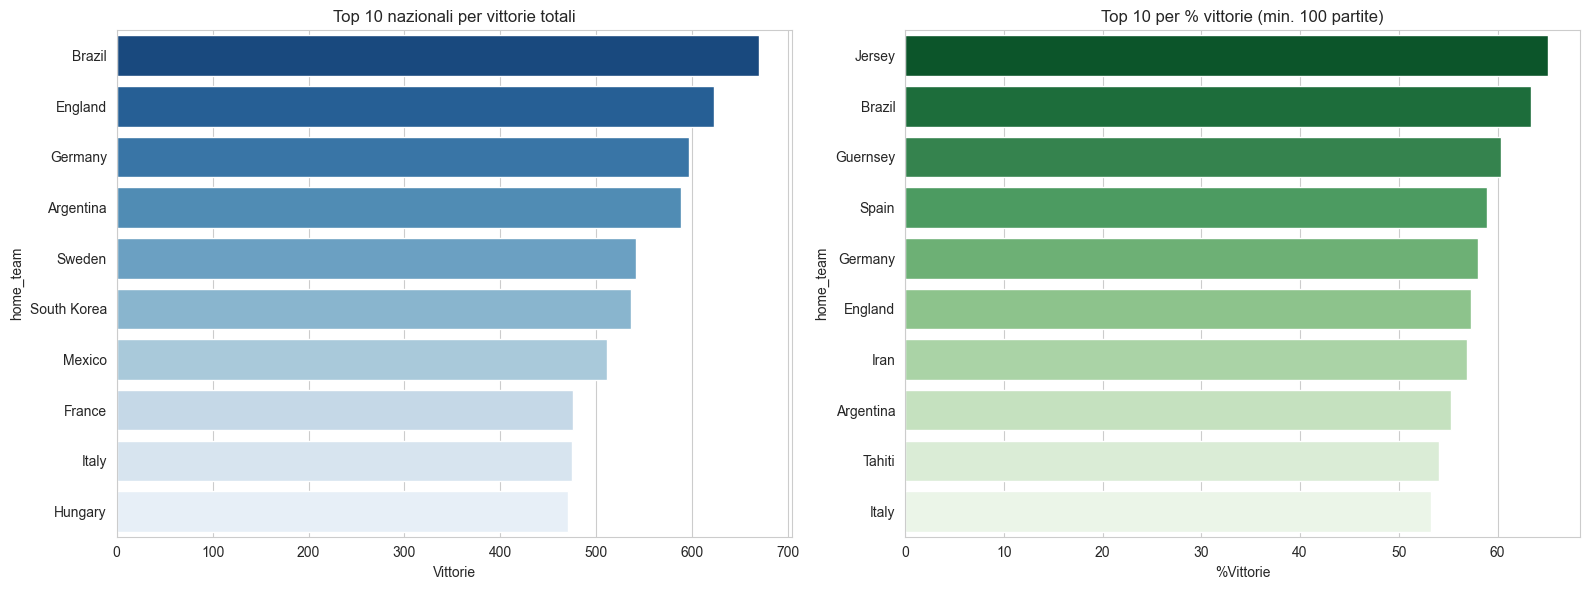

In [15]:
fig, axes= plt.subplots(1, 2, figsize=(16,6))

# Grafico 1: Top 10 per vittorie totali

top10_vittorie=vittorie_totali.head(10)
sns.barplot(x=top10_vittorie.values, y=top10_vittorie.index, ax=axes[0],palette="Blues_r")
axes[0].set_title("Top 10 nazionali per vittorie totali")
axes[0].set_xlabel("Vittorie")

# Grafico 2: Top 10 per percentuale vittorie
top10_perc=percentuale_vittorie.head(10)
sns.barplot(x=top10_perc.values, y=top10_perc.index, ax=axes[1],palette="Greens_r")
axes[1].set_title("Top 10 per % vittorie (min. 100 partite)")
axes[1].set_xlabel("%Vittorie")

plt.tight_layout()
plt.show()




### 📝 Risposta Q2

Il **Brasile** è la nazionale con più vittorie in assoluto (670), seguita da Inghilterra (623) e Germania (597). L'Italia è nona con 475 vittorie.

In percentuale di vittorie però la classifica cambia: Jersey (65.1%) e Guernsey (60.4%) guidano, ma sono squadre che giocano quasi solo in tornei minori tra isole. Tra le grandi nazionali, il **Brasile** conferma il primato con il 63.4%, seguito da Spagna (58.9%) e Germania (58.0%). L'Italia ha una percentuale del 53.3% — vince poco più di una partita su due.

## 🇮🇹 Q3 — Il record dell'Italia: vittorie, pareggi, sconfitte e il decennio migliore/peggiore

In [ ]:
italia=df[(df["home_team"]=="Italy")] | (df["away_team"]=="Italy")